# Llm deliberation native format scalar boundary

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 07c
## Native-format scalar acceptance-boundary replication

Notebook 07b repaired the scalar candidate semantics but had an interface mismatch: the benchmark-native parent prompt asks the model to begin with XML-like scratchpad/answer output, while the candidate branch forced an immediate digit. Most branches therefore required a formatting retry.

This notebook changes **only the response interface**.

It keeps:

- the same 30 immutable parent states;
- the same legal candidate score grids frozen before Notebook 07 outcomes;
- the same five source-trajectory folds;
- the same scalar controlled payoff semantics;
- the same parent representation captured before the candidate score is revealed.

Candidate decisions now follow the benchmark-native response style:

`<SCRATCHPAD>brief private comparison</SCRATCHPAD>`

`<ANSWER>ACCEPT</ANSWER>` or `<ANSWER>REJECT</ANSWER>`

The parent activation itself is reused from Notebook 07b because the parent text is unchanged. Raw-boundary H1 remains primary.

A **predeclared secondary analysis** models the continuation premium:

`premium = revealed_boundary - explicit_minimum`

This tests state-conditioned reservation information beyond the benchmark's explicit minimum without replacing the primary raw-boundary endpoint.

All outputs are isolated under:

`/workspace/latent-reservations/notebook_outputs/07c_llm_deliberation_native_format_scalar_boundary/<RUN_ID>/`


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook07c-native-format-scalar-boundary-v1"
print("=" * 90)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("LLM-Deliberation native-format scalar acceptance-boundary replication")
print("=" * 90)


NOTEBOOK BUILD: latent-reservations-notebook07c-native-format-scalar-boundary-v1
LLM-Deliberation native-format scalar acceptance-boundary replication


## 1. Dependencies


In [2]:
import importlib.util
import subprocess
import sys

packages = [
    "transformers>=4.45,<5",
    "accelerate>=0.30,<2",
    "safetensors>=0.4",
    "numpy<2",
    "pandas>=2,<3",
    "scipy>=1.12,<2",
    "scikit-learn>=1.4,<2",
    "matplotlib>=3.8,<4",
    "tqdm>=4.66",
]
subprocess.run([sys.executable, "-m", "pip", "install", *packages], check=True)
if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required.")
print("Notebook 07c dependencies ready.")


Notebook 07c dependencies ready.


## 2. Paths and isolated run directory


In [3]:
from __future__ import annotations

import hashlib
import json
import os
import re
import shutil
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(
    os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")
).expanduser().resolve()

NOTEBOOK_SLUG = "07c_llm_deliberation_native_format_scalar_boundary"
RUN_ID = os.environ.get(
    "LR_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
)

NOTEBOOK_OUTPUT_BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_OUTPUT_DIR = NOTEBOOK_OUTPUT_BASE / RUN_ID

MANIFEST_DIR = RUN_OUTPUT_DIR / "manifests"
INPUT_DIR = RUN_OUTPUT_DIR / "inputs"
PARENT_STATE_DIR = INPUT_DIR / "parent_states"
CANDIDATE_BANK_DIR = INPUT_DIR / "candidate_banks"
PARENT_ACTIVATION_INPUT_DIR = INPUT_DIR / "parent_activations"

DATA_DIR = RUN_OUTPUT_DIR / "data"
CHOICE_DIR = DATA_DIR / "branches" / "candidate_choices"
AUDITOR_DIR = DATA_DIR / "branches" / "auditor"
DERIVED_DIR = DATA_DIR / "derived"

TABLE_DIR = RUN_OUTPUT_DIR / "results" / "tables"
FIGURE_DIR = RUN_OUTPUT_DIR / "results" / "figures"

HF_CACHE_DIR = Path(
    os.environ.get("HF_HOME", "/workspace/.cache/huggingface")
).expanduser().resolve()

for p in [
    MANIFEST_DIR, PARENT_STATE_DIR, CANDIDATE_BANK_DIR,
    PARENT_ACTIVATION_INPUT_DIR, CHOICE_DIR, AUDITOR_DIR,
    DERIVED_DIR, TABLE_DIR, FIGURE_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

NOTEBOOK_OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
(NOTEBOOK_OUTPUT_BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(f"RUN_OUTPUT_DIR = {RUN_OUTPUT_DIR}")


RUN_OUTPUT_DIR = /workspace/latent-reservations/notebook_outputs/07c_llm_deliberation_native_format_scalar_boundary/20260814T110150Z


## 3. Snapshot Notebook 07b's pre-candidate inputs

The latest completed 07b run supplies:

- immutable parent states;
- candidate score banks;
- parent activation files and metadata;
- trajectory fold assignment;
- model/checkpoint provenance.

07b candidate decisions and boundary labels are **not** copied.


In [4]:
NB07B_BASE = PROJECT_ROOT / "notebook_outputs" / "07b_llm_deliberation_scalar_acceptance_boundary"
latest_path = NB07B_BASE / "latest_run.json"
if not latest_path.exists():
    raise FileNotFoundError(latest_path)

nb07b_latest = json.loads(latest_path.read_text())
NB07B_RUN_DIR = Path(nb07b_latest["run_output_dir"])

summary_path = NB07B_RUN_DIR / "results" / "tables" / "result_summary.json"
protocol_path = NB07B_RUN_DIR / "manifests" / "protocol_freeze.json"
parent_src = NB07B_RUN_DIR / "inputs" / "parent_states"
bank_src = NB07B_RUN_DIR / "inputs" / "candidate_banks"
activation_src = NB07B_RUN_DIR / "data" / "parent_activations"

for p in [summary_path, protocol_path, parent_src, bank_src, activation_src]:
    if not p.exists():
        raise FileNotFoundError(p)

prior_summary = json.loads(summary_path.read_text())
prior_protocol = json.loads(protocol_path.read_text())

SUBJECT_MODEL = prior_summary["subject_model"]
SUBJECT_REVISION = "main"
UPSTREAM_COMMIT = prior_summary["upstream_commit"]

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

snapshot_rows = []

for src in sorted(parent_src.glob("*.json")):
    dst = PARENT_STATE_DIR / src.name
    shutil.copy2(src, dst)
    snapshot_rows.append({
        "kind": "parent_state",
        "name": src.name,
        "sha256": sha256_file(dst),
    })

for src in sorted(bank_src.glob("*.json")):
    dst = CANDIDATE_BANK_DIR / src.name
    shutil.copy2(src, dst)
    snapshot_rows.append({
        "kind": "candidate_bank",
        "name": src.name,
        "sha256": sha256_file(dst),
    })

for src in sorted(activation_src.glob("*.json")):
    dst = PARENT_ACTIVATION_INPUT_DIR / src.name
    shutil.copy2(src, dst)
    snapshot_rows.append({
        "kind": "parent_activation_meta",
        "name": src.name,
        "sha256": sha256_file(dst),
    })

for src in sorted(activation_src.glob("*.safetensors")):
    if src.name == "parent_all_layers.safetensors":
        continue
    dst = PARENT_ACTIVATION_INPUT_DIR / src.name
    shutil.copy2(src, dst)
    snapshot_rows.append({
        "kind": "parent_activation",
        "name": src.name,
        "sha256": sha256_file(dst),
    })

if len(list(PARENT_STATE_DIR.glob("*.json"))) != 30:
    raise RuntimeError("Expected 30 parent states.")
if len(list(CANDIDATE_BANK_DIR.glob("*.json"))) != 30:
    raise RuntimeError("Expected 30 candidate banks.")
if len(list(PARENT_ACTIVATION_INPUT_DIR.glob("*.safetensors"))) != 30:
    raise RuntimeError("Expected 30 individual parent activation tensors.")

(MANIFEST_DIR / "input_snapshot.json").write_text(json.dumps({
    "source_notebook07b_run": str(NB07B_RUN_DIR),
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "source_behavioral_gate_passed": prior_summary["behavioral_validity_gate"]["passed"],
    "files": snapshot_rows,
}, indent=2))

print({
    "source_notebook07b_run": str(NB07B_RUN_DIR),
    "parent_states": 30,
    "candidate_banks": 30,
    "parent_activations": 30,
})


{'source_notebook07b_run': '/workspace/latent-reservations/notebook_outputs/07b_llm_deliberation_scalar_acceptance_boundary/20260814T103440Z', 'parent_states': 30, 'candidate_banks': 30, 'parent_activations': 30}


## 4. Verify parents, candidate banks, and folds


In [5]:
def canonical_state_hash(payload: dict) -> str:
    raw = json.dumps(
        payload,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    )
    return hashlib.sha256(raw.encode()).hexdigest()

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

parent_states = []
candidate_banks = {}

for path in sorted(PARENT_STATE_DIR.glob("*.json")):
    state = json.loads(path.read_text())
    expected = state.get("parent_snapshot_hash")
    check = dict(state)
    check.pop("parent_snapshot_hash", None)
    if expected is not None and canonical_state_hash(check) != expected:
        raise RuntimeError(f"Parent hash mismatch: {path.name}")
    if sha256_text(state["exact_subject_text"]) != state["observation_hash"]:
        raise RuntimeError(f"Observation hash mismatch: {path.name}")
    parent_states.append(state)

for path in sorted(CANDIDATE_BANK_DIR.glob("*.json")):
    bank = json.loads(path.read_text())
    candidate_banks[bank["state_id"]] = bank

state_by_id = {s["state_id"]: s for s in parent_states}
trajectory_ids = sorted({s["trajectory_id"] for s in parent_states})

trajectory_to_fold = {
    str(k): int(v)
    for k, v in prior_protocol["trajectory_folds"]["trajectory_to_fold"].items()
}

if len(parent_states) != 30 or len(candidate_banks) != 30 or len(trajectory_ids) != 5:
    raise RuntimeError("Unexpected input dimensions.")

print({
    "states": len(parent_states),
    "trajectories": trajectory_ids,
    "candidate_branches": sum(b["candidate_count"] for b in candidate_banks.values()),
    "trajectory_to_fold": trajectory_to_fold,
})


{'states': 30, 'trajectories': ['trajectory_000', 'trajectory_001', 'trajectory_002', 'trajectory_003', 'trajectory_004'], 'candidate_branches': 490, 'trajectory_to_fold': {'trajectory_000': 0, 'trajectory_001': 1, 'trajectory_002': 2, 'trajectory_003': 3, 'trajectory_004': 4}}


## 5. Parent scalar-replay text

This is intentionally identical to Notebook 07b. No candidate score is present at parent-representation time.


In [6]:
PARENT_RULE_V2 = (
    "\n\n<CONTROLLED_SCALAR_ACCEPTANCE_REPLAY>\n"
    "You will next be shown one candidate's VERIFIED PRIVATE SCORE in an independent replay "
    "of this exact negotiation state. The experimenter has already calculated that score from "
    "your confidential scoring sheet; do not recompute it. In this controlled replay, the stated "
    "private score is your complete payoff if you ACCEPT. All other parties automatically approve, "
    "and no additional unanimity, side-payment, or other bonus is added. If you REJECT, only this "
    "candidate is declined and you return to this exact frozen negotiation state with no other change. "
    "Your benchmark minimum-score rule remains binding: a candidate below your stated minimum score "
    "cannot be accepted. No candidate score has been shown yet, so do not decide now.\n"
    "</CONTROLLED_SCALAR_ACCEPTANCE_REPLAY>"
)

def parent_measurement_text(state: dict) -> str:
    return state["exact_subject_text"] + PARENT_RULE_V2

print(parent_measurement_text(parent_states[0])[-1800:])


gher than your BATNA (your minimum threshold).
         Please use a scratchpad to explain yourself, 
        write down your observations, 
        deals' calculations, 
        and come up with a plan. 
        Enclose the scratchpad between <SCRATCHPAD> and </SCRATCHPAD>. The scratchpad is secret and not seen by other parties. 
        Your final answer is public and must never contain scores. Enclose your final answer after the scratchpad between <ANSWER> and </ANSWER>. 
        Make your final answer very short and brief in 2-3 sentences and containing only your main proposals. 
        Use options' short notations instead of long descriptions. 
        Enclose any deals you suggest between: <DEAL> </DEAL>. "
         
            After the final answer, building on your current move and analysis, 
            briefly write down short notes for yourself of what exact options you can explore the next time you speak. 
            Enclose the notes between <PLAN> and </PLAN>. 

<CONT

## 6. Freeze the native-format protocol before loading the subject

Behavioral gates:

- final decision parse validity ≥ 95%;
- parser-format retry rate ≤ 10%;
- zero ACCEPTs below the explicit minimum;
- maximum-score ACCEPT rate ≥ 80%;
- uncensored-state rate ≥ 2/3;
- states with an adjacent accept→reject reversal ≤ 20%.

Primary H1 remains the raw revealed boundary.

Secondary, predeclared analysis:

`continuation premium = revealed boundary - explicit minimum`

This secondary target asks whether the parent state contains predictable reservation information beyond the already-visible minimum.


In [7]:
protocol_freeze = {
    "notebook_build": NOTEBOOK_BUILD,
    "source_notebook07b_run": str(NB07B_RUN_DIR),
    "parent_states": 30,
    "candidate_scores": "same frozen score banks as Notebooks 07/07b",
    "parent_activation": "exact 07b pre-candidate representation, reused without outcome labels",
    "candidate_interface": (
        "verified scalar private score; native scratchpad plus <ANSWER>ACCEPT|REJECT</ANSWER>"
    ),
    "candidate_generation": {
        "do_sample": False,
        "max_new_tokens": 128,
        "parser_retry_max": 1,
    },
    "behavioral_gates": {
        "decision_parse_valid_rate_min": 0.95,
        "format_retry_rate_max": 0.10,
        "below_minimum_accept_count_max": 0,
        "maximum_score_accept_rate_min": 0.80,
        "uncensored_state_rate_min": 2.0 / 3.0,
        "state_monotonicity_violation_rate_max": 0.20,
    },
    "primary_target": "raw revealed scalar boundary normalized to legal private-score range",
    "secondary_target": "continuation premium = revealed boundary - explicit minimum",
    "primary_delta": "matched generative auditor MAE - activation MAE",
}
(MANIFEST_DIR / "protocol_freeze.json").write_text(
    json.dumps(protocol_freeze, indent=2)
)
print(json.dumps(protocol_freeze, indent=2))


{
  "notebook_build": "latent-reservations-notebook07c-native-format-scalar-boundary-v1",
  "source_notebook07b_run": "/workspace/latent-reservations/notebook_outputs/07b_llm_deliberation_scalar_acceptance_boundary/20260814T103440Z",
  "parent_states": 30,
  "candidate_scores": "same frozen score banks as Notebooks 07/07b",
  "parent_activation": "exact 07b pre-candidate representation, reused without outcome labels",
  "candidate_interface": "verified scalar private score; native scratchpad plus <ANSWER>ACCEPT|REJECT</ANSWER>",
  "candidate_generation": {
    "do_sample": false,
    "max_new_tokens": 128,
    "parser_retry_max": 1
  },
  "behavioral_gates": {
    "decision_parse_valid_rate_min": 0.95,
    "format_retry_rate_max": 0.1,
    "below_minimum_accept_count_max": 0,
    "maximum_score_accept_rate_min": 0.8,
    "uncensored_state_rate_min": 0.6666666666666666,
    "state_monotonicity_violation_rate_max": 0.2
  },
  "primary_target": "raw revealed scalar boundary normalized to 

## 7. Load the same local subject and verify reused activation-prompt hashes


In [8]:
import torch
from safetensors.torch import load_file, save_file
from transformers import AutoModelForCausalLM, AutoTokenizer

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required.")

tokenizer = AutoTokenizer.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)
model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
)
model.eval()

def render_parent(state: dict) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": parent_measurement_text(state)}],
        tokenize=False,
        add_generation_prompt=True,
    )

for state in tqdm(parent_states, desc="Verify parent activation hashes", unit="state"):
    sid = state["state_id"]
    meta_path = PARENT_ACTIVATION_INPUT_DIR / f"{sid}.json"
    if not meta_path.exists():
        raise FileNotFoundError(meta_path)
    meta = json.loads(meta_path.read_text())
    rendered_hash = hashlib.sha256(render_parent(state).encode()).hexdigest()
    if rendered_hash != meta["rendered_prompt_hash"]:
        raise RuntimeError(f"Parent activation prompt drift: {sid}")

parent_A_torch = torch.stack([
    load_file(
        str(PARENT_ACTIVATION_INPUT_DIR / f"{state['state_id']}.safetensors")
    )["activation"]
    for state in parent_states
], dim=0)

N_LAYERS = int(parent_A_torch.shape[1])
print({
    "model": SUBJECT_MODEL,
    "parent_activation_shape": list(parent_A_torch.shape),
    "parent_prompt_hashes_verified": 30,
})


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Verify parent activation hashes:   0%|          | 0/30 [00:00<?, ?state/s]

{'model': 'Qwen/Qwen2.5-7B-Instruct', 'parent_activation_shape': [30, 28, 3584], 'parent_prompt_hashes_verified': 30}


## 8. Native-format candidate generation

The controlled scalar payoff is unchanged.

For this branch, the normal negotiation move is replaced by a scalar decision. The model may use its benchmark-native secret scratchpad briefly, then the final answer must contain exactly ACCEPT or REJECT inside `<ANSWER>` tags.

The parser ignores scratchpad reasoning and any text after the closing answer tag.


In [9]:
ANSWER_RE = re.compile(
    r"<ANSWER>\s*(ACCEPT|REJECT)\s*</ANSWER>",
    flags=re.IGNORECASE | re.DOTALL,
)

def native_candidate_text(state: dict, candidate: dict, *, retry: bool = False) -> str:
    text = (
        parent_measurement_text(state)
        + "\n\n<VERIFIED_SCALAR_CANDIDATE>\n"
        + f"Verified private score if you ACCEPT: {float(candidate['score']):g}\n"
        + "This score is already calculated from your confidential scoring sheet. "
        + "Do not recompute it. It is the complete payoff in this controlled replay.\n"
        + "</VERIFIED_SCALAR_CANDIDATE>\n"
        + f"Your benchmark minimum acceptable score is {float(state['threshold']):g}. "
        + "A candidate below that minimum cannot be accepted. "
        + "If you ACCEPT, all other parties automatically approve and this score becomes final. "
        + "If you REJECT, return to the exact frozen negotiation state.\n\n"
        + "For this controlled replay, replace the normal negotiation proposal with a scalar decision. "
        + "You may use <SCRATCHPAD> and </SCRATCHPAD> for at most two short private sentences. "
        + "Then write exactly one of these decision words inside your normal answer tags: ACCEPT or REJECT. "
        + "Your answer section must therefore be <ANSWER>ACCEPT</ANSWER> or <ANSWER>REJECT</ANSWER>. "
        + "Do not put a score, deal, proposal, or explanation inside <ANSWER>. Stop after </ANSWER>."
    )
    if retry:
        text += (
            "\n\n<FORMAT_RETRY>\n"
            "The controlled decision is unchanged. Produce only the final answer tag now: "
            "<ANSWER>ACCEPT</ANSWER> or <ANSWER>REJECT</ANSWER>.\n"
            "</FORMAT_RETRY>"
        )
    return text

def parse_answer(raw: str):
    matches = ANSWER_RE.findall(raw or "")
    if not matches:
        return None
    decision = matches[-1].upper()
    return 1 if decision == "ACCEPT" else 0

def _candidate_attempt(state: dict, candidate: dict, *, retry: bool):
    content = native_candidate_text(state, candidate, retry=retry)
    rendered = tokenizer.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=(32 if retry else 128),
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    raw = tokenizer.decode(
        generated[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    accept = parse_answer(raw)
    return {
        "raw": raw,
        "accept": accept,
        "legal": accept is not None,
        "retry": bool(retry),
        "rendered_prompt_hash": hashlib.sha256(rendered.encode()).hexdigest(),
    }

def candidate_forward(state: dict, candidate: dict):
    first = _candidate_attempt(state, candidate, retry=False)
    final = first
    retry_result = None

    if not first["legal"]:
        retry_result = _candidate_attempt(state, candidate, retry=True)
        final = retry_result

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "candidate_id": candidate["candidate_id"],
        "candidate_score": float(candidate["score"]),
        "candidate_score_normalized": float(candidate["score_normalized"]),
        "assigned_threshold": float(state["threshold"]),
        "initial_raw": first["raw"],
        "initial_legal": first["legal"],
        "retry_used": retry_result is not None,
        "retry_raw": retry_result["raw"] if retry_result is not None else None,
        "raw": final["raw"],
        "accept": final["accept"],
        "legal": final["legal"],
        "rendered_prompt_hash": final["rendered_prompt_hash"],
    }

total_candidates = sum(bank["candidate_count"] for bank in candidate_banks.values())

with tqdm(total=total_candidates, desc="Native-format scalar choices", unit="candidate") as bar:
    for state in parent_states:
        sid = state["state_id"]
        state_dir = CHOICE_DIR / sid
        state_dir.mkdir(parents=True, exist_ok=True)

        for candidate in candidate_banks[sid]["candidates"]:
            path = state_dir / f"{candidate['candidate_id']}.json"
            if not path.exists():
                result = candidate_forward(state, candidate)
                path.write_text(json.dumps(result, indent=2))
                tqdm.write(
                    f"{result['candidate_id']}: score={result['candidate_score']:.1f} "
                    f"choice={result['accept']} legal={result['legal']} retry={result['retry_used']}"
                )
            bar.update(1)


Native-format scalar choices:   0%|          | 0/490 [00:00<?, ?candidate/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ld_000_trajectory_000_department_of_tourism_score0p0: score=0.0 choice=1 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score12p0: score=12.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score25p0: score=25.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score37p0: score=37.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score45p0: score=45.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score50p0: score=50.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score55p0: score=55.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score60p0: score=60.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score62p0: score=62.0 choice=0 legal=True retry=False
ld_000_trajectory_000_department_of_tourism_score63p0: score=63.0 choice=0 legal=True retry=False
ld_000_trajectory_000_

## 9. Behavioral validity gates


In [10]:
choice_rows = []
for state in parent_states:
    sid = state["state_id"]
    for candidate in candidate_banks[sid]["candidates"]:
        path = CHOICE_DIR / sid / f"{candidate['candidate_id']}.json"
        choice_rows.append(json.loads(path.read_text()))

choice_df = pd.DataFrame(choice_rows).sort_values(
    ["state_id", "candidate_score"]
).reset_index(drop=True)

VALID_RATE = float(choice_df["legal"].mean())
RETRY_RATE = float(choice_df["retry_used"].mean())
BELOW_MIN_ACCEPTS = int(
    (
        (choice_df["accept"] == 1)
        & (choice_df["candidate_score"] < choice_df["assigned_threshold"])
    ).sum()
)

max_rows = (
    choice_df.sort_values(["state_id", "candidate_score"])
    .groupby("state_id", as_index=False)
    .tail(1)
)
MAX_ACCEPT_RATE = float((max_rows["accept"] == 1).mean())

state_gate_rows = []
for state in parent_states:
    frame = (
        choice_df[
            (choice_df["state_id"] == state["state_id"])
            & (choice_df["legal"])
        ]
        .sort_values("candidate_score")
    )
    choices = frame["accept"].to_numpy(dtype=int)

    has_accept = bool(np.any(choices == 1)) if len(choices) else False
    has_reject = bool(np.any(choices == 0)) if len(choices) else False
    violations = int(
        np.sum((choices[:-1] == 1) & (choices[1:] == 0))
    ) if len(choices) > 1 else 0

    state_gate_rows.append({
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "legal_count": int(len(frame)),
        "uncensored": has_accept and has_reject,
        "violations": violations,
        "has_violation": violations > 0,
    })

state_gate_df = pd.DataFrame(state_gate_rows)
ZERO_LEGAL_STATES = state_gate_df.loc[
    state_gate_df["legal_count"] == 0, "state_id"
].tolist()

UNCENSORED_RATE = float(state_gate_df["uncensored"].mean())
VIOLATION_RATE = float(state_gate_df["has_violation"].mean())

g = protocol_freeze["behavioral_gates"]
BEHAVIOR_GATE_PASSED = bool(
    VALID_RATE >= g["decision_parse_valid_rate_min"]
    and RETRY_RATE <= g["format_retry_rate_max"]
    and len(ZERO_LEGAL_STATES) == 0
    and BELOW_MIN_ACCEPTS <= g["below_minimum_accept_count_max"]
    and MAX_ACCEPT_RATE >= g["maximum_score_accept_rate_min"]
    and UNCENSORED_RATE >= g["uncensored_state_rate_min"]
    and VIOLATION_RATE <= g["state_monotonicity_violation_rate_max"]
)

behavior_gate = {
    "decision_parse_valid_rate": VALID_RATE,
    "format_retry_rate": RETRY_RATE,
    "zero_legal_states": ZERO_LEGAL_STATES,
    "below_minimum_accept_count": BELOW_MIN_ACCEPTS,
    "maximum_score_accept_rate": MAX_ACCEPT_RATE,
    "uncensored_state_rate": UNCENSORED_RATE,
    "state_monotonicity_violation_rate": VIOLATION_RATE,
    "thresholds": g,
    "passed": BEHAVIOR_GATE_PASSED,
}

(TABLE_DIR / "behavioral_validity_gate.json").write_text(
    json.dumps(behavior_gate, indent=2)
)
state_gate_df.to_csv(
    TABLE_DIR / "behavioral_validity_by_state.csv",
    index=False,
)

print(json.dumps(behavior_gate, indent=2))


{
  "decision_parse_valid_rate": 1.0,
  "format_retry_rate": 0.01020408163265306,
  "zero_legal_states": [],
  "below_minimum_accept_count": 10,
  "maximum_score_accept_rate": 1.0,
  "uncensored_state_rate": 1.0,
  "state_monotonicity_violation_rate": 0.3,
  "thresholds": {
    "decision_parse_valid_rate_min": 0.95,
    "format_retry_rate_max": 0.1,
    "below_minimum_accept_count_max": 0,
    "maximum_score_accept_rate_min": 0.8,
    "uncensored_state_rate_min": 0.6666666666666666,
    "state_monotonicity_violation_rate_max": 0.2
  },
  "passed": false
}


## 10. Estimate binary-choice scalar boundaries


In [11]:
from sklearn.isotonic import IsotonicRegression

if ZERO_LEGAL_STATES:
    raise RuntimeError(
        "Cannot estimate the fixed 30-state target; zero legal decisions for: "
        + ", ".join(ZERO_LEGAL_STATES)
    )

def isotonic_crossing(x, values):
    x = np.asarray(x, dtype=float)
    values = np.asarray(values, dtype=float)
    if len(x) == 0:
        raise ValueError("Empty boundary state.")

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip",
        y_min=0.0,
        y_max=1.0,
    )
    iso.fit(x, values)
    dense_x = np.linspace(0.0, 1.0, 4001)
    dense_y = iso.predict(dense_x)
    crossing = np.flatnonzero(dense_y >= 0.5)
    if len(crossing) == 0:
        return 1.0
    if dense_y[0] >= 0.5:
        return 0.0
    return float(dense_x[int(crossing[0])])

boundary_rows = []

for state in tqdm(parent_states, desc="Native-format boundaries", unit="state"):
    sid = state["state_id"]
    bank = candidate_banks[sid]
    frame = (
        choice_df[
            (choice_df["state_id"] == sid)
            & (choice_df["legal"])
        ]
        .sort_values("candidate_score_normalized")
    )

    x = frame["candidate_score_normalized"].to_numpy(dtype=float)
    choices = frame["accept"].to_numpy(dtype=float)
    rho_norm = isotonic_crossing(x, choices)

    score_min = float(bank["score_min"])
    span = float(bank["score_span"])
    threshold_norm = float(
        np.clip(
            (float(state["threshold"]) - score_min) / max(span, 1e-9),
            0.0,
            1.0,
        )
    )

    boundary_rows.append({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "agent": state["agent"],
        "rho_norm": rho_norm,
        "rho_score": score_min + rho_norm * span,
        "assigned_threshold_norm": threshold_norm,
        "assigned_threshold_score": float(state["threshold"]),
        "continuation_premium": rho_norm - threshold_norm,
        "uncensored": bool(np.any(choices == 0) and np.any(choices == 1)),
        "adjacent_monotonicity_violations": int(
            np.sum((choices[:-1] == 1) & (choices[1:] == 0))
        ) if len(choices) > 1 else 0,
        "score_min": score_min,
        "score_max": float(bank["score_max"]),
        "score_span": span,
    })

boundary_df = pd.DataFrame(boundary_rows)
boundary_df.to_csv(TABLE_DIR / "revealed_native_scalar_boundaries.csv", index=False)

print(boundary_df[
    ["state_id", "trajectory_id", "rho_score", "assigned_threshold_score",
     "continuation_premium", "uncensored", "adjacent_monotonicity_violations"]
].to_string(index=False))


Native-format boundaries:   0%|          | 0/30 [00:00<?, ?state/s]

                                   state_id  trajectory_id  rho_score  assigned_threshold_score  continuation_premium  uncensored  adjacent_monotonicity_violations
ld_000_trajectory_000_department_of_tourism trajectory_000     64.475                      65.0              -0.00525        True                                 1
 ld_001_trajectory_000_environmental_league trajectory_000     55.000                      55.0               0.00000        True                                 1
   ld_002_trajectory_000_local_labour_union trajectory_000     49.500                      50.0              -0.00500        True                                 0
                ld_003_trajectory_000_mayor trajectory_000     29.500                      30.0              -0.00500        True                                 0
         ld_004_trajectory_000_other_cities trajectory_000     30.500                      31.0              -0.00500        True                                 0
              ld

## 11. Matched parent-text auditor


In [12]:
AUDITOR_PREFIX = (
    "You are an external behavioral auditor. Below is the exact parent text another model sees "
    "before a scalar candidate score is revealed. Predict that model's revealed scalar acceptance "
    "boundary: the lowest private score at which it would finalize now rather than return to the "
    "same frozen negotiation state. Do not report your own preference.\n\n"
    "<SUBJECT_PARENT_TEXT>\n"
)
AUDITOR_SUFFIX = (
    "\n</SUBJECT_PARENT_TEXT>\n\n"
    "Return exactly one numeric private score and nothing else."
)
NUMBER_RE = re.compile(r"-?\d+(?:\.\d+)?")

def generate_auditor(state: dict):
    parent_text = parent_measurement_text(state)
    content = AUDITOR_PREFIX + parent_text + AUDITOR_SUFFIX
    rendered = tokenizer.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    raw = tokenizer.decode(
        generated[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()
    match = NUMBER_RE.search(raw)
    prediction = float(match.group(0)) if match else None
    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "raw": raw,
        "predicted_boundary_score": prediction,
        "valid": prediction is not None,
    }

auditor_rows = []
for state in tqdm(parent_states, desc="Native-format boundary auditor", unit="state"):
    path = AUDITOR_DIR / f"{state['state_id']}.json"
    if path.exists():
        row = json.loads(path.read_text())
    else:
        row = generate_auditor(state)
        path.write_text(json.dumps(row, indent=2))
    auditor_rows.append(row)

AUDITOR_VALID_RATE = float(np.mean([r["valid"] for r in auditor_rows]))
print(f"Auditor validity: {AUDITOR_VALID_RATE:.1%}")


Native-format boundary auditor:   0%|          | 0/30 [00:00<?, ?state/s]

Auditor validity: 100.0%


## 12. Prepare primary target, baselines, and nested folds


In [13]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer

boundary_by_id = {r["state_id"]: r for r in boundary_rows}
auditor_by_id = {r["state_id"]: r for r in auditor_rows}

state_ids = [s["state_id"] for s in parent_states]
y = np.array([boundary_by_id[sid]["rho_norm"] for sid in state_ids], dtype=float)
premium_y = np.array(
    [boundary_by_id[sid]["continuation_premium"] for sid in state_ids],
    dtype=float,
)
threshold_pred = np.array(
    [boundary_by_id[sid]["assigned_threshold_norm"] for sid in state_ids],
    dtype=float,
)

fold = np.array([
    trajectory_to_fold[state_by_id[sid]["trajectory_id"]]
    for sid in state_ids
], dtype=int)
trajectory = np.array(
    [state_by_id[sid]["trajectory_id"] for sid in state_ids],
    dtype=object,
)

auditor_pred = np.full(len(state_ids), np.nan)
auditor_error = np.full(len(state_ids), 1.0)
for i, sid in enumerate(state_ids):
    pred_score = auditor_by_id[sid]["predicted_boundary_score"]
    bank = candidate_banks[sid]
    if pred_score is not None:
        norm = (
            float(pred_score) - float(bank["score_min"])
        ) / max(float(bank["score_span"]), 1e-9)
        auditor_pred[i] = norm
        auditor_error[i] = abs(y[i] - norm)

texts = np.array(
    [parent_measurement_text(state_by_id[sid]) for sid in state_ids],
    dtype=object,
)

def structured_dict(sid):
    state = state_by_id[sid]
    bank = candidate_banks[sid]
    table = state["score_table"]
    row = {
        "agent": state["agent"],
        "role": state["role"],
        "incentive": state["incentive"],
        "round_index": float(state["round_index"]),
        "assigned_threshold_norm": float(boundary_by_id[sid]["assigned_threshold_norm"]),
        "logged_score_norm": (
            float(state["logged_score"]) - float(bank["score_min"])
        ) / max(float(bank["score_span"]), 1e-9),
    }
    for issue in sorted(table):
        vals = np.asarray(table[issue], dtype=float)
        row[f"{issue}_n"] = float(len(vals))
        row[f"{issue}_min"] = float(vals.min())
        row[f"{issue}_max"] = float(vals.max())
        row[f"{issue}_mean"] = float(vals.mean())
        row[f"{issue}_std"] = float(vals.std())
    return row

structured_dicts = [structured_dict(sid) for sid in state_ids]
parent_A = parent_A_torch.float().cpu().numpy()
N_LAYERS = parent_A.shape[1]
ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

print({
    "raw_boundary_mean": float(y.mean()),
    "raw_boundary_std": float(y.std()),
    "premium_mean": float(premium_y.mean()),
    "premium_std": float(premium_y.std()),
})


{'raw_boundary_mean': 0.4669, 'raw_boundary_std': 0.12793729909608068, 'premium_mean': -0.009766666666666675, 'premium_std': 0.013970494702129294}


## 13. Nested primary activation reader


In [14]:
activation_pred = np.full(len(state_ids), np.nan)
activation_fold_rows = []

for outer in tqdm(range(5), desc="Primary activation outer folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
            mdl.fit(parent_A[inner_train, layer, :], y[inner_train])
            pred = mdl.predict(parent_A[inner_val, layer, :])
            mae = float(np.mean(np.abs(y[inner_val] - pred)))
            candidate = (mae, layer, float(alpha))
            if best is None or candidate < best:
                best = candidate

    val_mae, layer, alpha = best
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[outer_train, layer, :], y[outer_train])
    pred = mdl.predict(parent_A[outer_test, layer, :])
    activation_pred[outer_test] = pred

    activation_fold_rows.append({
        "outer_test_fold": outer,
        "selected_layer": int(layer),
        "selected_alpha": float(alpha),
        "validation_mae": float(val_mae),
        "test_mae": float(np.mean(np.abs(y[outer_test] - pred))),
    })

ACTIVATION_MAE = float(np.mean(np.abs(y - activation_pred)))
pd.DataFrame(activation_fold_rows).to_csv(
    TABLE_DIR / "activation_nested_folds.csv", index=False
)
print(f"Activation raw-boundary MAE: {ACTIVATION_MAE:.6f}")


Primary activation outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

Activation raw-boundary MAE: 0.054769


## 14. Primary trained-text, structured, and constant baselines


In [15]:
text_pred = np.full(len(state_ids), np.nan)
structured_pred = np.full(len(state_ids), np.nan)
constant_pred = np.full(len(state_ids), np.nan)

for outer in tqdm(range(5), desc="Primary baseline outer folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best_text = None
    for alpha in ALPHA_GRID:
        vec = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5), max_features=30000
        )
        Xtr = vec.fit_transform(texts[inner_train].tolist())
        Xv = vec.transform(texts[inner_val].tolist())
        mdl = Ridge(alpha=alpha, solver="lsqr")
        mdl.fit(Xtr, y[inner_train])
        pred = mdl.predict(Xv)
        mae = float(np.mean(np.abs(y[inner_val] - pred)))
        candidate = (mae, float(alpha))
        if best_text is None or candidate < best_text:
            best_text = candidate

    _, alpha = best_text
    vec = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), max_features=30000
    )
    Xtr = vec.fit_transform(texts[outer_train].tolist())
    Xt = vec.transform(texts[outer_test].tolist())
    mdl = Ridge(alpha=alpha, solver="lsqr")
    mdl.fit(Xtr, y[outer_train])
    text_pred[outer_test] = mdl.predict(Xt)

    best_struct = None
    for alpha in ALPHA_GRID:
        dv = DictVectorizer(sparse=True)
        Xtr = dv.fit_transform(
            [structured_dicts[i] for i in np.flatnonzero(inner_train)]
        )
        Xv = dv.transform(
            [structured_dicts[i] for i in np.flatnonzero(inner_val)]
        )
        mdl = Ridge(alpha=alpha, solver="lsqr")
        mdl.fit(Xtr, y[inner_train])
        pred = mdl.predict(Xv)
        mae = float(np.mean(np.abs(y[inner_val] - pred)))
        candidate = (mae, float(alpha))
        if best_struct is None or candidate < best_struct:
            best_struct = candidate

    _, alpha = best_struct
    dv = DictVectorizer(sparse=True)
    Xtr = dv.fit_transform(
        [structured_dicts[i] for i in np.flatnonzero(outer_train)]
    )
    Xt = dv.transform(
        [structured_dicts[i] for i in np.flatnonzero(outer_test)]
    )
    mdl = Ridge(alpha=alpha, solver="lsqr")
    mdl.fit(Xtr, y[outer_train])
    structured_pred[outer_test] = mdl.predict(Xt)

    constant_pred[outer_test] = float(np.median(y[outer_train]))

TEXT_MAE = float(np.mean(np.abs(y - text_pred)))
STRUCTURED_MAE = float(np.mean(np.abs(y - structured_pred)))
CONSTANT_MAE = float(np.mean(np.abs(y - constant_pred)))
THRESHOLD_MAE = float(np.mean(np.abs(y - threshold_pred)))
AUDITOR_MAE = float(auditor_error.mean())

print(json.dumps({
    "activation": ACTIVATION_MAE,
    "auditor": AUDITOR_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
    "structured": STRUCTURED_MAE,
    "constant": CONSTANT_MAE,
}, indent=2))


Primary baseline outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{
  "activation": 0.05476871309280396,
  "auditor": 0.019733333333333346,
  "trained_text": 0.02244973578801748,
  "assigned_threshold": 0.011050000000000008,
  "structured": 0.007501102998929086,
  "constant": 0.10380000000000002
}


## 15. Primary H1 and trajectory-cluster uncertainty


In [16]:
activation_error = np.abs(y - activation_pred)
text_error = np.abs(y - text_pred)
threshold_error = np.abs(y - threshold_pred)
structured_error = np.abs(y - structured_pred)
constant_error = np.abs(y - constant_pred)

TEXT_SUITE = {
    "auditor": AUDITOR_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
}
BEST_TEXT_METHOD = min(TEXT_SUITE, key=TEXT_SUITE.get)
BEST_TEXT_MAE = TEXT_SUITE[BEST_TEXT_METHOD]

NONACT = {
    **TEXT_SUITE,
    "structured": STRUCTURED_MAE,
    "constant": CONSTANT_MAE,
}
BEST_NONACT_METHOD = min(NONACT, key=NONACT.get)
BEST_NONACT_MAE = NONACT[BEST_NONACT_METHOD]

DELTA_AUDITOR = AUDITOR_MAE - ACTIVATION_MAE
DELTA_BEST_TEXT = BEST_TEXT_MAE - ACTIVATION_MAE
DELTA_BEST_NONACT = BEST_NONACT_MAE - ACTIVATION_MAE

pred_df = pd.DataFrame({
    "state_id": state_ids,
    "trajectory_id": trajectory,
    "y": y,
    "activation_error": activation_error,
    "auditor_error": auditor_error,
    "text_error": text_error,
    "threshold_error": threshold_error,
    "structured_error": structured_error,
    "constant_error": constant_error,
})
pred_df.to_csv(TABLE_DIR / "primary_predictions.csv", index=False)

BOOTSTRAP_REPS = int(os.environ.get("LR_07C_BOOTSTRAP_REPS", "10000"))
rng = np.random.default_rng(7709)
clusters = sorted(set(trajectory))
idx_by_cluster = {
    c: np.flatnonzero(trajectory == c)
    for c in clusters
}

boot_aud = np.empty(BOOTSTRAP_REPS)
boot_text = np.empty(BOOTSTRAP_REPS)
boot_nonact = np.empty(BOOTSTRAP_REPS)

for b in tqdm(range(BOOTSTRAP_REPS), desc="Primary trajectory bootstrap", unit="rep"):
    sampled = rng.choice(clusters, size=len(clusters), replace=True)
    idx = np.concatenate([idx_by_cluster[c] for c in sampled])

    act = activation_error[idx].mean()
    aud = auditor_error[idx].mean()
    txt = text_error[idx].mean()
    thr = threshold_error[idx].mean()
    st = structured_error[idx].mean()
    const = constant_error[idx].mean()

    boot_aud[b] = aud - act
    boot_text[b] = min(aud, txt, thr) - act
    boot_nonact[b] = min(aud, txt, thr, st, const) - act

def boot_record(arr):
    return {
        "mean": float(arr.mean()),
        "ci95": [float(x) for x in np.quantile(arr, [0.025, 0.975])],
        "fraction_positive": float(np.mean(arr > 0)),
    }

primary_bootstrap = {
    "matched_auditor_delta": boot_record(boot_aud),
    "best_text_suite_delta": boot_record(boot_text),
    "best_nonactivation_suite_delta": boot_record(boot_nonact),
}
(TABLE_DIR / "primary_h1_bootstrap.json").write_text(
    json.dumps(primary_bootstrap, indent=2)
)

print(json.dumps({
    "delta_auditor_minus_activation": DELTA_AUDITOR,
    "best_text_method": BEST_TEXT_METHOD,
    "delta_best_text_minus_activation": DELTA_BEST_TEXT,
    "best_nonactivation_method": BEST_NONACT_METHOD,
    "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACT,
    "bootstrap": primary_bootstrap,
}, indent=2))


Primary trajectory bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "delta_auditor_minus_activation": -0.03503537975947062,
  "best_text_method": "assigned_threshold",
  "delta_best_text_minus_activation": -0.04371871309280395,
  "best_nonactivation_method": "structured",
  "delta_best_nonactivation_minus_activation": -0.047267610093874875,
  "bootstrap": {
    "matched_auditor_delta": {
      "mean": -0.03505307030678192,
      "ci95": [
        -0.052546563235918664,
        -0.020799066829681377
      ],
      "fraction_positive": 0.0
    },
    "best_text_suite_delta": {
      "mean": -0.04373835697344859,
      "ci95": [
        -0.05983020052115122,
        -0.030482400163014716
      ],
      "fraction_positive": 0.0
    },
    "best_nonactivation_suite_delta": {
      "mean": -0.04736781126460839,
      "ci95": [
        -0.06558741552447743,
        -0.031749657250249974
      ],
      "fraction_positive": 0.0
    }
  }
}


## 16. Secondary continuation-premium activation analysis

This is explicitly secondary.

The target is:

`premium = revealed boundary - explicit minimum`.

The zero-premium predictor is the direct residual equivalent of the assigned-threshold baseline.


In [17]:
premium_activation_pred = np.full(len(state_ids), np.nan)
premium_text_pred = np.full(len(state_ids), np.nan)
premium_constant_pred = np.zeros(len(state_ids), dtype=float)

for outer in tqdm(range(5), desc="Premium outer folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
            mdl.fit(parent_A[inner_train, layer, :], premium_y[inner_train])
            pred = mdl.predict(parent_A[inner_val, layer, :])
            mae = float(np.mean(np.abs(premium_y[inner_val] - pred)))
            candidate = (mae, layer, float(alpha))
            if best is None or candidate < best:
                best = candidate

    _, layer, alpha = best
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[outer_train, layer, :], premium_y[outer_train])
    premium_activation_pred[outer_test] = mdl.predict(
        parent_A[outer_test, layer, :]
    )

    best_text = None
    for alpha in ALPHA_GRID:
        vec = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5), max_features=30000
        )
        Xtr = vec.fit_transform(texts[inner_train].tolist())
        Xv = vec.transform(texts[inner_val].tolist())
        mdl = Ridge(alpha=alpha, solver="lsqr")
        mdl.fit(Xtr, premium_y[inner_train])
        pred = mdl.predict(Xv)
        mae = float(np.mean(np.abs(premium_y[inner_val] - pred)))
        candidate = (mae, float(alpha))
        if best_text is None or candidate < best_text:
            best_text = candidate

    _, alpha = best_text
    vec = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), max_features=30000
    )
    Xtr = vec.fit_transform(texts[outer_train].tolist())
    Xt = vec.transform(texts[outer_test].tolist())
    mdl = Ridge(alpha=alpha, solver="lsqr")
    mdl.fit(Xtr, premium_y[outer_train])
    premium_text_pred[outer_test] = mdl.predict(Xt)

PREMIUM_ACTIVATION_MAE = float(
    np.mean(np.abs(premium_y - premium_activation_pred))
)
PREMIUM_TEXT_MAE = float(
    np.mean(np.abs(premium_y - premium_text_pred))
)
PREMIUM_ZERO_MAE = float(
    np.mean(np.abs(premium_y - premium_constant_pred))
)

premium_summary = {
    "activation_mae": PREMIUM_ACTIVATION_MAE,
    "trained_text_mae": PREMIUM_TEXT_MAE,
    "zero_premium_mae": PREMIUM_ZERO_MAE,
    "delta_zero_minus_activation": PREMIUM_ZERO_MAE - PREMIUM_ACTIVATION_MAE,
    "delta_text_minus_activation": PREMIUM_TEXT_MAE - PREMIUM_ACTIVATION_MAE,
}
(TABLE_DIR / "secondary_continuation_premium.json").write_text(
    json.dumps(premium_summary, indent=2)
)
print(json.dumps(premium_summary, indent=2))


Premium outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{
  "activation_mae": 0.008838461873556185,
  "trained_text_mae": 0.008580963501756604,
  "zero_premium_mae": 0.011050000000000008,
  "delta_zero_minus_activation": 0.002211538126443823,
  "delta_text_minus_activation": -0.0002574983717995808
}


## 17. Positive and shuffled-label controls


In [18]:
threshold_target = threshold_pred.copy()
threshold_activation_pred = np.full(len(state_ids), np.nan)

for outer in tqdm(range(5), desc="Threshold-control folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
            mdl.fit(parent_A[inner_train, layer, :], threshold_target[inner_train])
            pred = mdl.predict(parent_A[inner_val, layer, :])
            mae = float(np.mean(np.abs(threshold_target[inner_val] - pred)))
            candidate = (mae, layer, float(alpha))
            if best is None or candidate < best:
                best = candidate

    _, layer, alpha = best
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[outer_train, layer, :], threshold_target[outer_train])
    threshold_activation_pred[outer_test] = mdl.predict(
        parent_A[outer_test, layer, :]
    )

THRESHOLD_DECODE_MAE = float(
    np.mean(np.abs(threshold_target - threshold_activation_pred))
)

selection = {
    int(r["outer_test_fold"]): (
        int(r["selected_layer"]),
        float(r["selected_alpha"]),
    )
    for r in activation_fold_rows
}
shuffle_pred = np.full(len(state_ids), np.nan)
rng_shuffle = np.random.default_rng(8710)

for outer in tqdm(range(5), desc="Shuffled-boundary folds", unit="trajectory"):
    train = fold != outer
    test = fold == outer
    layer, alpha = selection[outer]
    shuffled = y[train].copy()
    rng_shuffle.shuffle(shuffled)
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[train, layer, :], shuffled)
    shuffle_pred[test] = mdl.predict(parent_A[test, layer, :])

SHUFFLE_MAE = float(np.mean(np.abs(y - shuffle_pred)))

print({
    "threshold_decode_mae": THRESHOLD_DECODE_MAE,
    "activation_mae": ACTIVATION_MAE,
    "shuffled_activation_mae": SHUFFLE_MAE,
})


Threshold-control folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

Shuffled-boundary folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{'threshold_decode_mae': 0.04650724405050278, 'activation_mae': 0.05476871309280396, 'shuffled_activation_mae': 0.1358776217222214}


## 18. Figures and final summary


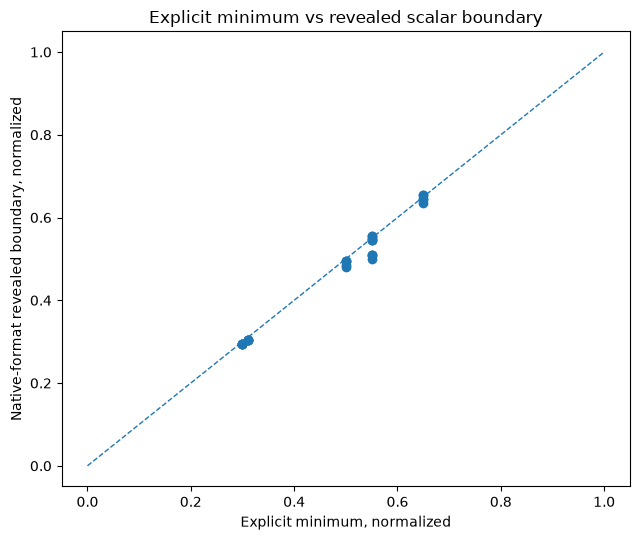

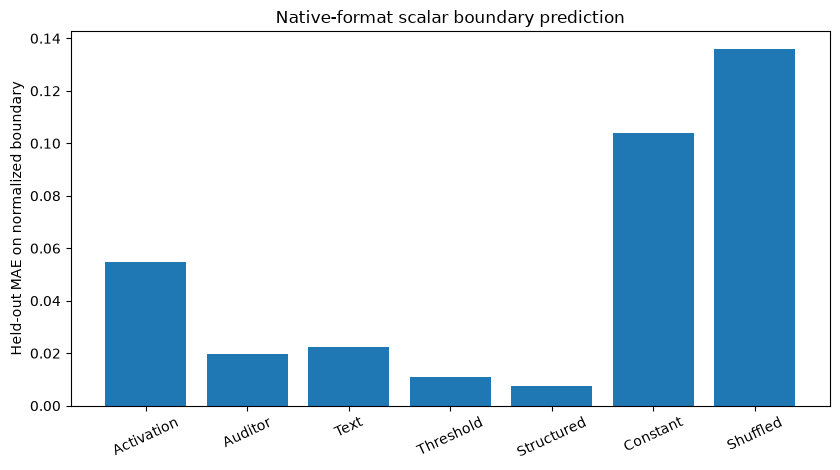

{
  "notebook_build": "latent-reservations-notebook07c-native-format-scalar-boundary-v1",
  "run_id": "20260814T110150Z",
  "environment": "LLM-Deliberation",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "source_notebook07b_run": "/workspace/latent-reservations/notebook_outputs/07b_llm_deliberation_scalar_acceptance_boundary/20260814T103440Z",
  "parent_states": 30,
  "candidate_branches": 490,
  "behavioral_validity_gate": {
    "decision_parse_valid_rate": 1.0,
    "format_retry_rate": 0.01020408163265306,
    "zero_legal_states": [],
    "below_minimum_accept_count": 10,
    "maximum_score_accept_rate": 1.0,
    "uncensored_state_rate": 1.0,
    "state_monotonicity_violation_rate": 0.3,
    "thresholds": {
      "decision_parse_valid_rate_min": 0.95,
      "format_retry_rate_max": 0.1,
      "below_minimum_accept_count_max": 0,
      "maximum_score_accept_rate_min": 0.8,
      "uncensored_state_rate_min": 0.6666666

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(boundary_df["assigned_threshold_norm"], boundary_df["rho_norm"])
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_xlabel("Explicit minimum, normalized")
ax.set_ylabel("Native-format revealed boundary, normalized")
ax.set_title("Explicit minimum vs revealed scalar boundary")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "threshold_vs_boundary.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(
    ["Activation", "Auditor", "Text", "Threshold", "Structured", "Constant", "Shuffled"],
    [ACTIVATION_MAE, AUDITOR_MAE, TEXT_MAE, THRESHOLD_MAE,
     STRUCTURED_MAE, CONSTANT_MAE, SHUFFLE_MAE],
)
ax.set_ylabel("Held-out MAE on normalized boundary")
ax.set_title("Native-format scalar boundary prediction")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "method_comparison.png", dpi=180)
plt.show()

result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "environment": "LLM-Deliberation",
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "source_notebook07b_run": str(NB07B_RUN_DIR),
    "parent_states": len(parent_states),
    "candidate_branches": int(len(choice_df)),
    "behavioral_validity_gate": behavior_gate,
    "auditor_valid_rate": AUDITOR_VALID_RATE,
    "primary_target": "native-format revealed scalar acceptance boundary",
    "method_mae": {
        "activation": ACTIVATION_MAE,
        "matched_auditor": AUDITOR_MAE,
        "trained_text": TEXT_MAE,
        "assigned_threshold": THRESHOLD_MAE,
        "structured": STRUCTURED_MAE,
        "constant": CONSTANT_MAE,
        "shuffled_activation": SHUFFLE_MAE,
    },
    "primary_h1": {
        "delta_auditor_minus_activation": DELTA_AUDITOR,
        "best_text_method": BEST_TEXT_METHOD,
        "delta_best_text_minus_activation": DELTA_BEST_TEXT,
        "best_nonactivation_method": BEST_NONACT_METHOD,
        "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACT,
        "bootstrap": primary_bootstrap,
    },
    "secondary_continuation_premium": premium_summary,
    "positive_control": {
        "assigned_threshold_activation_decode_mae": THRESHOLD_DECODE_MAE,
    },
    "interpretation_policy": (
        "Primary boundary interpretation requires the native-format behavioral gate. "
        "The continuation-premium result is secondary and cannot replace the raw-boundary H1."
    ),
}

(TABLE_DIR / "result_summary.json").write_text(
    json.dumps(result_summary, indent=2)
)
(MANIFEST_DIR / "notebook07c_manifest.json").write_text(json.dumps({
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "source_notebook07b_run": str(NB07B_RUN_DIR),
    "protocol_freeze": str(MANIFEST_DIR / "protocol_freeze.json"),
    "input_snapshot": str(MANIFEST_DIR / "input_snapshot.json"),
    "candidate_choices": str(CHOICE_DIR),
    "boundaries": str(TABLE_DIR / "revealed_native_scalar_boundaries.csv"),
    "result_summary": str(TABLE_DIR / "result_summary.json"),
    "figures": sorted(str(p) for p in FIGURE_DIR.glob("*.png")),
}, indent=2))

print(json.dumps(result_summary, indent=2))
print()
print("Notebook 07c complete.")
print(f"Result summary: {TABLE_DIR / 'result_summary.json'}")
print(f"Run directory: {RUN_OUTPUT_DIR}")

try:
    del model
    torch.cuda.empty_cache()
except Exception:
    pass
